## **Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


## **Load Dataset**

In [3]:
# Load Data
df = pd.read_csv('data/volve_production_data.csv')
df

# Exclude columns
exclude_columns = ['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'Faktor Pembagi', 'BORE_WI_VOL']
df = df.drop(columns=exclude_columns)
df.head()

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG Choke size,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,15/9-F-1 C,0.0,0.00000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,WI
1,2014-04-08,15/9-F-1 C,0.0,NaN,NaN,NaN,0.010031,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
2,2014-04-09,15/9-F-1 C,0.0,NaN,NaN,NaN,0.009790,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
3,2014-04-10,15/9-F-1 C,0.0,NaN,NaN,NaN,0.005458,0.00000,0.00000,0.00000,0.0,0.0,0.0,production,OP
4,2014-04-11,15/9-F-1 C,0.0,310.37614,96.87589,277.27826,0.012160,33.09788,10.47992,33.07195,0.0,0.0,0.0,production,OP


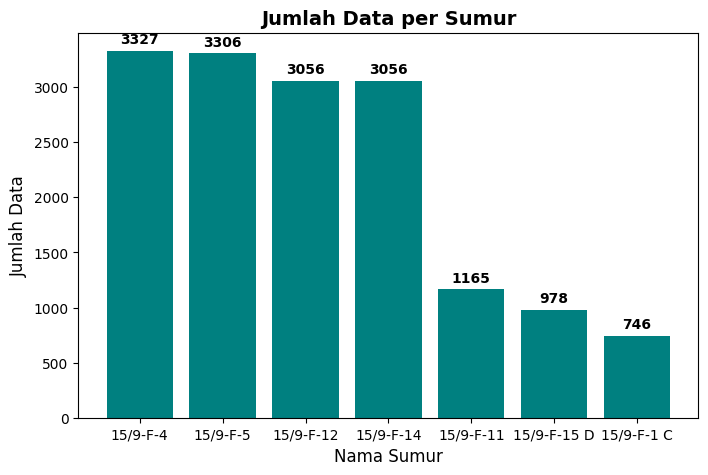

In [4]:
entity_counts = df['NPD_WELL_BORE_NAME'].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(entity_counts.index, entity_counts.values, color='teal')

plt.bar_label(bars, padding=3, fmt='%d', fontsize=10, fontweight='bold')

plt.title('Jumlah Data per Sumur', fontsize=14, fontweight='bold')
plt.xlabel('Nama Sumur', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)


plt.show()

## **EDA**

In [5]:
df.isnull().sum()

DATEPRD                        0
NPD_WELL_BORE_NAME             0
ON_STREAM_HRS                285
AVG_DOWNHOLE_PRESSURE       6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_DP_TUBING               6654
AVG Choke size                 0
AVG_WHP_P                   6479
AVG_WHT_P                   6488
DP_CHOKE_SIZE                294
BORE_OIL_VOL                6473
BORE_GAS_VOL                6473
BORE_WAT_VOL                6473
FLOW_KIND                      0
WELL_TYPE                      0
dtype: int64

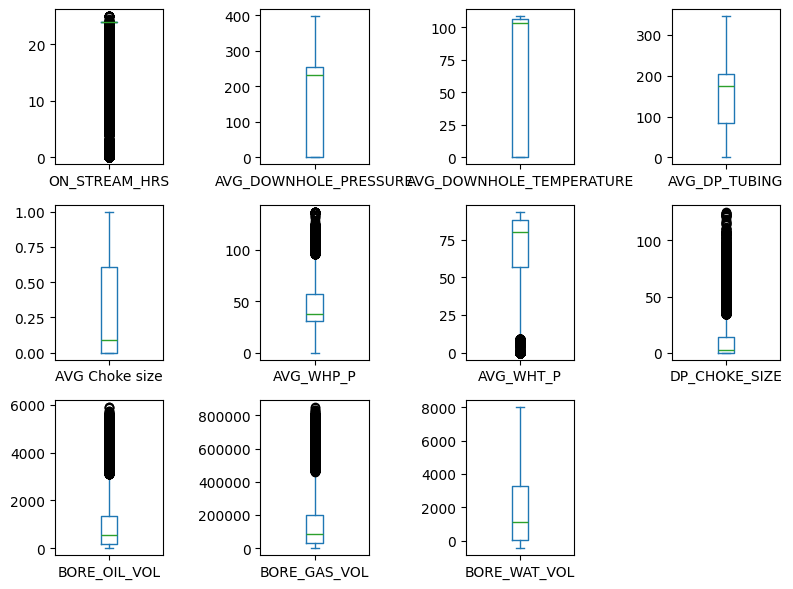

In [6]:
df_numerik = df.select_dtypes(include=['float64'])

jumlah_kolom = len(df_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(8, 2 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

## **Preprocessing**

In [7]:
# Drop row kondisi tertentu

# BORE_OIL_VOL > 0
df = df[df['BORE_OIL_VOL'] > 0]

# FLOW_KIND = 'production'
df = df[df['FLOW_KIND'] == 'production']

# WELL_TYPE = 'OP'
df = df[df['WELL_TYPE'] == 'OP']

print(len(df))

7999


In [8]:
# Standarasasi Format Date
df['DATEPRD'] = pd.to_datetime(df['DATEPRD'], format='%Y-%m-%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7999 entries, 15 to 15610
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   7999 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        7999 non-null   object        
 2   ON_STREAM_HRS             7999 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     7863 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  7863 non-null   float64       
 5   AVG_DP_TUBING             7863 non-null   float64       
 6   AVG Choke size            7999 non-null   float64       
 7   AVG_WHP_P                 7996 non-null   float64       
 8   AVG_WHT_P                 7996 non-null   float64       
 9   DP_CHOKE_SIZE             7996 non-null   float64       
 10  BORE_OIL_VOL              7999 non-null   float64       
 11  BORE_GAS_VOL              7999 non-null   float64       
 12  BORE_WAT_VOL           

### Split Entity

In [9]:
df['NPD_WELL_BORE_NAME'].unique()

array(['15/9-F-1 C', '15/9-F-11', '15/9-F-12', '15/9-F-14', '15/9-F-15 D',
       '15/9-F-5'], dtype=object)

In [10]:
df_f1 = df[df['NPD_WELL_BORE_NAME'] == '15/9-F-1 C']
df_f11 = df[df['NPD_WELL_BORE_NAME'] == '15/9-F-11']
df_f12 = df[df['NPD_WELL_BORE_NAME'] == '15/9-F-12']
df_f14 = df[df['NPD_WELL_BORE_NAME'] == '15/9-F-14']
df_f15 = df[df['NPD_WELL_BORE_NAME'] == '15/9-F-15 D']
df_f4 = df[df['NPD_WELL_BORE_NAME'] == '15/9-F-4']
df_f5 = df[df['NPD_WELL_BORE_NAME'] == '15/9-F-5']

In [11]:
print(len(df_f4))
print(len(df_f5))
print(len(df_f11))
print(len(df_f12))
print(len(df_f14))
print(len(df_f15))
print(len(df_f1))

0
121
1123
2836
2723
767
429


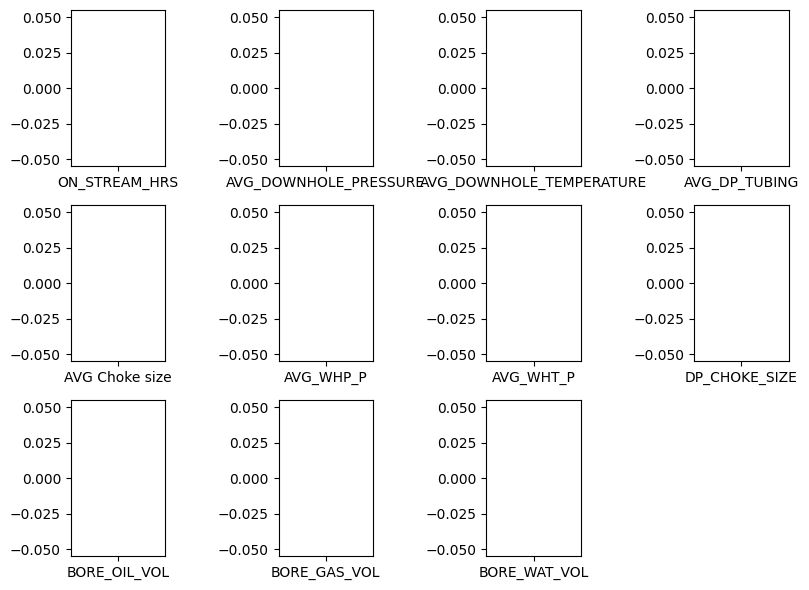

In [12]:
df_f4_numerik = df_f4.select_dtypes(include=['float64'])

jumlah_kolom = len(df_f4_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_f4_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(8, 2 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

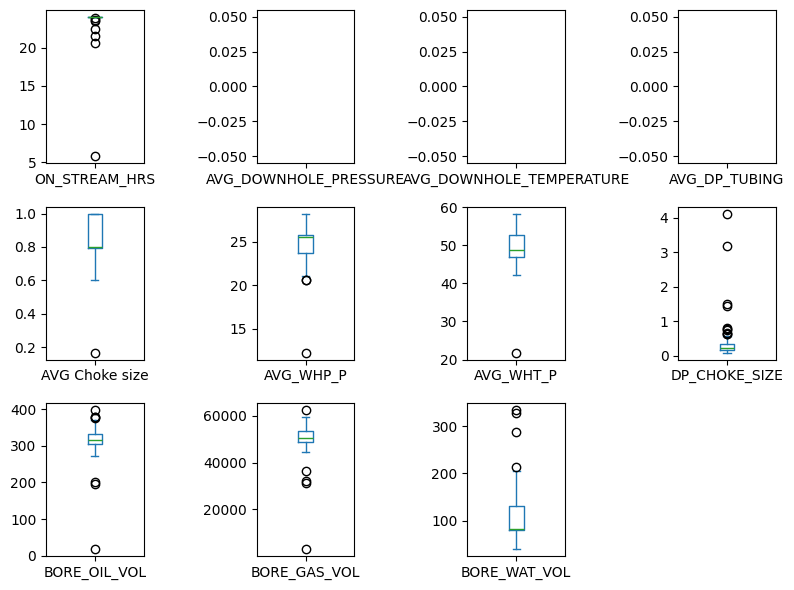

In [13]:
df_f5_numerik = df_f5.select_dtypes(include=['float64'])

jumlah_kolom = len(df_f5_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_f5_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(8, 2 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

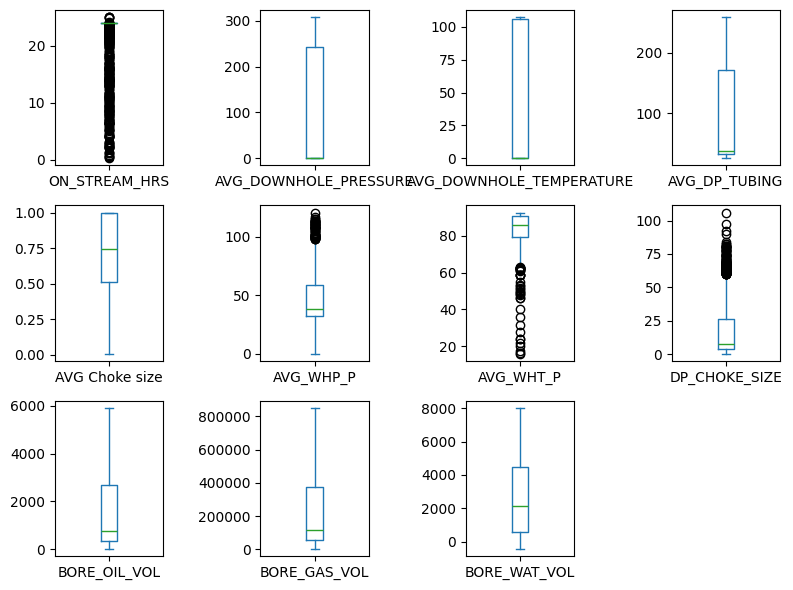

In [14]:
df_f12_numerik = df_f12.select_dtypes(include=['float64'])

jumlah_kolom = len(df_f12_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_f12_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(8, 2 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

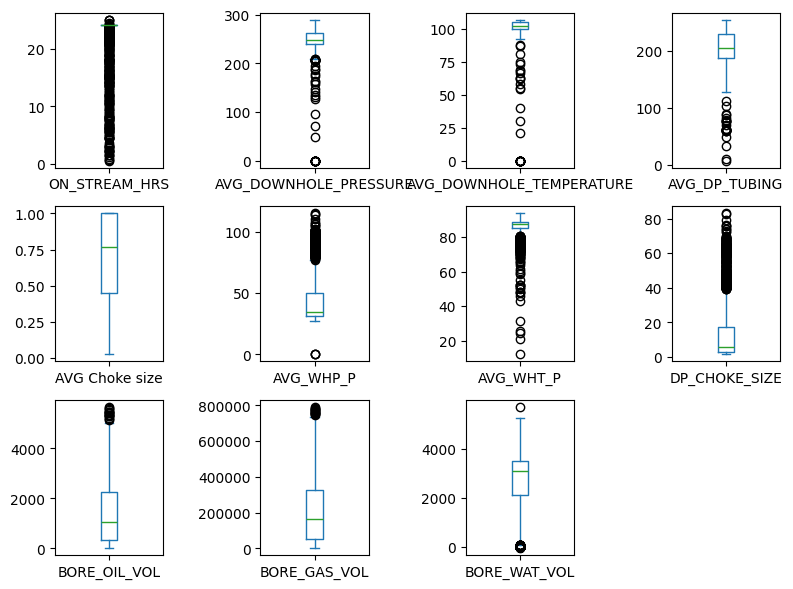

In [15]:
df_f14_numerik = df_f14.select_dtypes(include=['float64'])

jumlah_kolom = len(df_f14_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_f14_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(8, 2 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

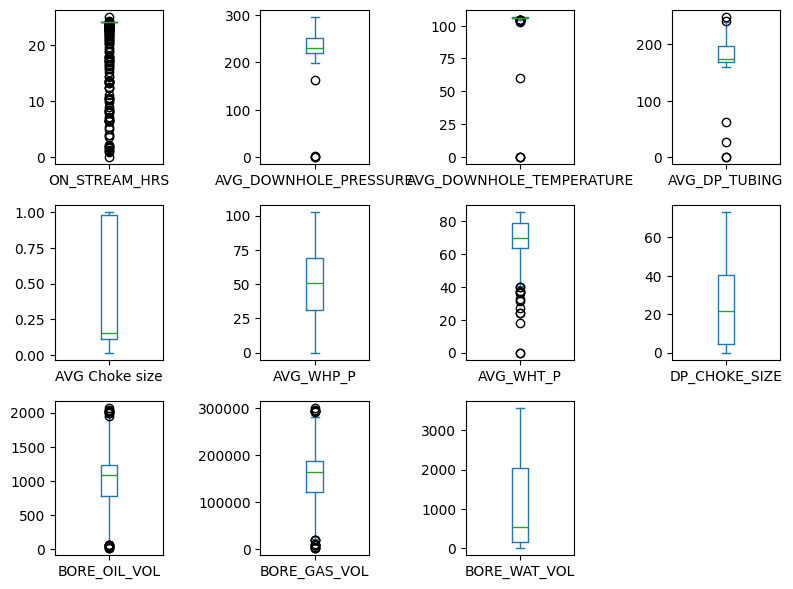

In [16]:
df_f11_numerik = df_f11.select_dtypes(include=['float64'])

jumlah_kolom = len(df_f11_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_f11_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(8, 2 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

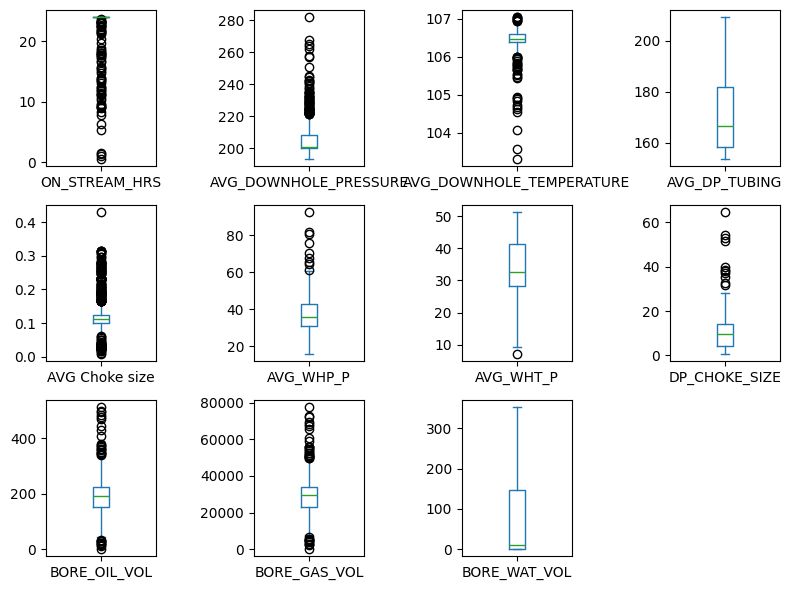

In [17]:
df_f15_numerik = df_f15.select_dtypes(include=['float64'])

jumlah_kolom = len(df_f15_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_f15_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(8, 2 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

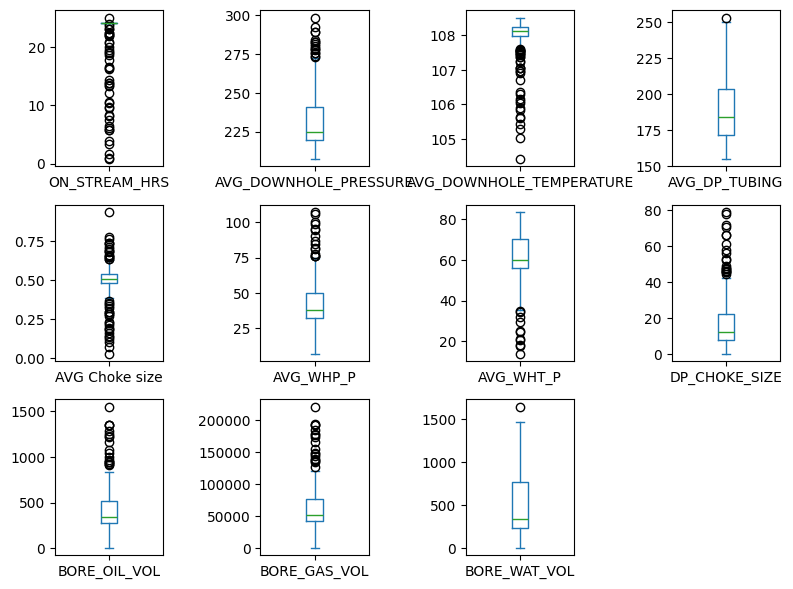

In [18]:
df_f1_numerik = df_f1.select_dtypes(include=['float64'])

jumlah_kolom = len(df_f1_numerik.columns)

kolom_grid = 4
baris_grid = math.ceil(jumlah_kolom / kolom_grid) 

df_f1_numerik.plot(
    kind='box', 
    subplots=True, 
    layout=(baris_grid, kolom_grid), 
    figsize=(8, 2 * baris_grid), 
    sharey=False 
)

plt.tight_layout()

plt.show()

In [19]:
print(len(df_f4))
print(len(df_f5))
print(len(df_f11))
print(len(df_f12))
print(len(df_f14))
print(len(df_f15))
print(len(df_f1))

0
121
1123
2836
2723
767
429


Selected Well Entity


> 15/9-F-12

> 15/9-F-14

In [20]:
df_f12.isnull().sum()

DATEPRD                     0
NPD_WELL_BORE_NAME          0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       6
AVG_DOWNHOLE_TEMPERATURE    6
AVG_DP_TUBING               6
AVG Choke size              0
AVG_WHP_P                   0
AVG_WHT_P                   0
DP_CHOKE_SIZE               0
BORE_OIL_VOL                0
BORE_GAS_VOL                0
BORE_WAT_VOL                0
FLOW_KIND                   0
WELL_TYPE                   0
dtype: int64

In [21]:
df_f12.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2836 entries, 1911 to 4930
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   2836 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        2836 non-null   object        
 2   ON_STREAM_HRS             2836 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     2830 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  2830 non-null   float64       
 5   AVG_DP_TUBING             2830 non-null   float64       
 6   AVG Choke size            2836 non-null   float64       
 7   AVG_WHP_P                 2836 non-null   float64       
 8   AVG_WHT_P                 2836 non-null   float64       
 9   DP_CHOKE_SIZE             2836 non-null   float64       
 10  BORE_OIL_VOL              2836 non-null   float64       
 11  BORE_GAS_VOL              2836 non-null   float64       
 12  BORE_WAT_VOL          

In [22]:
df_f12.dropna(inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_3992\3279117653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f12.dropna(inplace=True)


In [23]:
df_f12.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2830 entries, 1911 to 4930
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   2830 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        2830 non-null   object        
 2   ON_STREAM_HRS             2830 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     2830 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  2830 non-null   float64       
 5   AVG_DP_TUBING             2830 non-null   float64       
 6   AVG Choke size            2830 non-null   float64       
 7   AVG_WHP_P                 2830 non-null   float64       
 8   AVG_WHT_P                 2830 non-null   float64       
 9   DP_CHOKE_SIZE             2830 non-null   float64       
 10  BORE_OIL_VOL              2830 non-null   float64       
 11  BORE_GAS_VOL              2830 non-null   float64       
 12  BORE_WAT_VOL          

In [24]:
df_f12.isnull().sum()

DATEPRD                     0
NPD_WELL_BORE_NAME          0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_DP_TUBING               0
AVG Choke size              0
AVG_WHP_P                   0
AVG_WHT_P                   0
DP_CHOKE_SIZE               0
BORE_OIL_VOL                0
BORE_GAS_VOL                0
BORE_WAT_VOL                0
FLOW_KIND                   0
WELL_TYPE                   0
dtype: int64

In [25]:
df_f14.isnull().sum()

DATEPRD                     0
NPD_WELL_BORE_NAME          0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       6
AVG_DOWNHOLE_TEMPERATURE    6
AVG_DP_TUBING               6
AVG Choke size              0
AVG_WHP_P                   0
AVG_WHT_P                   0
DP_CHOKE_SIZE               0
BORE_OIL_VOL                0
BORE_GAS_VOL                0
BORE_WAT_VOL                0
FLOW_KIND                   0
WELL_TYPE                   0
dtype: int64

In [26]:
df_f14.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2723 entries, 5118 to 7956
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   2723 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        2723 non-null   object        
 2   ON_STREAM_HRS             2723 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     2717 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  2717 non-null   float64       
 5   AVG_DP_TUBING             2717 non-null   float64       
 6   AVG Choke size            2723 non-null   float64       
 7   AVG_WHP_P                 2723 non-null   float64       
 8   AVG_WHT_P                 2723 non-null   float64       
 9   DP_CHOKE_SIZE             2723 non-null   float64       
 10  BORE_OIL_VOL              2723 non-null   float64       
 11  BORE_GAS_VOL              2723 non-null   float64       
 12  BORE_WAT_VOL          

In [27]:
df_f14.dropna(inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_3992\2549102894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f14.dropna(inplace=True)


In [28]:
df_f14.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2717 entries, 5118 to 7956
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   2717 non-null   datetime64[ns]
 1   NPD_WELL_BORE_NAME        2717 non-null   object        
 2   ON_STREAM_HRS             2717 non-null   float64       
 3   AVG_DOWNHOLE_PRESSURE     2717 non-null   float64       
 4   AVG_DOWNHOLE_TEMPERATURE  2717 non-null   float64       
 5   AVG_DP_TUBING             2717 non-null   float64       
 6   AVG Choke size            2717 non-null   float64       
 7   AVG_WHP_P                 2717 non-null   float64       
 8   AVG_WHT_P                 2717 non-null   float64       
 9   DP_CHOKE_SIZE             2717 non-null   float64       
 10  BORE_OIL_VOL              2717 non-null   float64       
 11  BORE_GAS_VOL              2717 non-null   float64       
 12  BORE_WAT_VOL          

In [29]:
df_f14.isnull().sum()

DATEPRD                     0
NPD_WELL_BORE_NAME          0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_DP_TUBING               0
AVG Choke size              0
AVG_WHP_P                   0
AVG_WHT_P                   0
DP_CHOKE_SIZE               0
BORE_OIL_VOL                0
BORE_GAS_VOL                0
BORE_WAT_VOL                0
FLOW_KIND                   0
WELL_TYPE                   0
dtype: int64

## **Feature Engineering**

In [30]:
# Penambahan kolom baru untuk analisis lebih lanjut

# Water Cut
df['WAT_CUT'] = df['BORE_WAT_VOL'] / (df['BORE_OIL_VOL'] + df['BORE_WAT_VOL'])

# Oil Cut
df['OIL_CUT'] = df['BORE_OIL_VOL'] / (df['BORE_OIL_VOL'] + df['BORE_WAT_VOL'])

## **Feature Selection**

> 15/9-F-12

In [31]:
# Variabel yang akan digunakan untuk analisis lebih lanjut

var = ['AVG Choke size', 'DP_CHOKE_SIZE', 'ON_STREAM_HRS', 'AVG_DP_TUBING', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_WHP_P', 'AVG_WHT_P']

X_12 = df_f12[var]
y_oil_12 = df_f12["BORE_OIL_VOL"]
y_water_12 = df_f12["BORE_WAT_VOL"]


In [32]:
# Split Dataset

X_train_12, X_test_12, y_oil_train_12, y_oil_test_12 = train_test_split(X_12, y_oil_12, test_size=0.2, random_state=42)

X_train_12, X_test_12, y_water_train_12, y_water_test_12 = train_test_split(X_12, y_water_12, test_size=0.2, random_state=42)


> 15/9-F-14

In [33]:
# Variabel yang akan digunakan untuk analisis lebih lanjut

var = ['AVG Choke size', 'DP_CHOKE_SIZE', 'ON_STREAM_HRS', 'AVG_DP_TUBING', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_WHP_P', 'AVG_WHT_P']

X_14 = df_f14[var]
y_oil_14 = df_f14["BORE_OIL_VOL"]
y_water_14 = df_f14["BORE_WAT_VOL"]


In [34]:
# Split Dataset

X_train_14, X_test_14, y_oil_train_14, y_oil_test_14 = train_test_split(X_14, y_oil_14, test_size=0.2, random_state=42)

X_train_14, X_test_14, y_water_train_14, y_water_test_14 = train_test_split(X_14, y_water_14, test_size=0.2, random_state=42)


## **Modelling**

> SGD

In [36]:
# Training Model Oil
model_oil_sgd_12 = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(
        max_iter=1000,
        learning_rate='invscaling',
        eta0=0.01,
        random_state=42
    ))
])

model_oil_sgd_12.fit(X_train_12, y_oil_train_12)

Pipeline(steps=[('scaler', StandardScaler()),
                ('sgd', SGDRegressor(random_state=42))])

In [38]:
# Training Model Water
model_water_sgd_12 = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(
        max_iter=1000,
        learning_rate='invscaling',
        eta0=0.01,
        random_state=42
    ))
])

model_water_sgd_12.fit(X_train_12, y_oil_train_12)

Pipeline(steps=[('scaler', StandardScaler()),
                ('sgd', SGDRegressor(random_state=42))])

In [37]:
# Training Model Oil
model_oil_sgd_14 = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(
        max_iter=1000,
        learning_rate='invscaling',
        eta0=0.01,
        random_state=42
    ))
])

model_oil_sgd_14.fit(X_train_14, y_oil_train_14)

Pipeline(steps=[('scaler', StandardScaler()),
                ('sgd', SGDRegressor(random_state=42))])

In [39]:
# Training Model Water
model_water_sgd_14 = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(
        max_iter=1000,
        learning_rate='invscaling',
        eta0=0.01,
        random_state=42
    ))
])

model_water_sgd_14.fit(X_train_14, y_oil_train_14)

Pipeline(steps=[('scaler', StandardScaler()),
                ('sgd', SGDRegressor(random_state=42))])

In [40]:
# Prediction 12
oil_pred_sgd_12 = model_oil_sgd_12.predict(X_test_12)
water_pred_sgd_12 = model_water_sgd_12.predict(X_test_12)

# Prediction 14
oil_pred_sgd_14 = model_oil_sgd_14.predict(X_test_14)
water_pred_sgd_14 = model_water_sgd_14.predict(X_test_14)

In [41]:
oil_r2_12 = r2_score(y_oil_test_12, oil_pred_sgd_12)
oil_rmse_12 = np.sqrt(mean_squared_error(y_oil_test_12, oil_pred_sgd_12))
water_r2_12 = r2_score(y_water_test_12, water_pred_sgd_12)
water_rmse_12 = np.sqrt(mean_squared_error(y_water_test_12, water_pred_sgd_12))

oil_r2_14 = r2_score(y_oil_test_14, oil_pred_sgd_14)
oil_rmse_14 = np.sqrt(mean_squared_error(y_oil_test_14, oil_pred_sgd_14))
water_r2_14 = r2_score(y_water_test_14, water_pred_sgd_14)
water_rmse_14 = np.sqrt(mean_squared_error(y_water_test_14, water_pred_sgd_14))

tabel_evaluasi = pd.DataFrame({
    "Entity": ["15/9-F-12", "15/9-F-14"],
    "SGD Oil R2": [oil_r2_12, oil_r2_14],
    "SGD Oil RMSE": [oil_rmse_12, oil_rmse_14],
    "SGD Water R2": [water_r2_12, water_r2_14],
    "SGD Water RMSE": [water_rmse_12, water_rmse_14]
})

tabel_evaluasi = tabel_evaluasi.round(4)
tabel_evaluasi

,Entity,SGD Oil R2,SGD Oil RMSE,SGD Water R2,SGD Water RMSE
0,15/9-F-12,0.8234,704.4732,-1.6118,3056.1097
1,15/9-F-14,0.8552,490.5116,-2.7059,2514.3801


Selected Well
> 15/9-F-14

### Cross Validation

In [42]:
cv_scores = cross_val_score(model_oil_sgd_14, X_train_14, y_oil_train_14, cv=5, scoring='r2')

print("=== HASIL 5-FOLD CROSS VALIDATION (OIL RATE F-14) ===")
print(f"Skor R2 di tiap lipatan : {np.round(cv_scores, 4)}")
print(f"Rata-rata Skor R2       : {cv_scores.mean():.4f}")
print(f"Standar Deviasi         : {cv_scores.std():.4f} (Makin kecil makin stabil)")

=== HASIL 5-FOLD CROSS VALIDATION (OIL RATE F-14) ===
Skor R2 di tiap lipatan : [0.8388 0.8503 0.8534 0.8275 0.8536]
Rata-rata Skor R2       : 0.8447
Standar Deviasi         : 0.0102 (Makin kecil makin stabil)


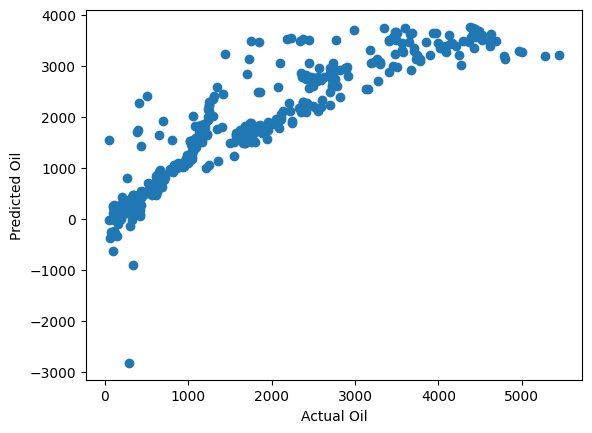

In [43]:
plt.scatter(y_oil_test_14, oil_pred_sgd_14)
plt.xlabel("Actual Oil")
plt.ylabel("Predicted Oil")
plt.show()